In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords
from matplotlib.ticker import MaxNLocator
import networkx as nx
import matplotlib.cm as cm

1° LIVELLO
analisi delle due fasi temporali
es. confrontare il volume della prima fase rispetto a quello della seconda fase

Fase 1
fase di shock e cronaca
28 Febbraio - 4 Marzo

Fase 2
fase di consolidamento e la polarizzazione
5 Marzo - 10 Marzo

In [9]:
df_fase1 = pd.read_csv('corpus_italia_dal_28_al_5.csv')
df_fase2 = pd.read_csv('corpus_italia_dal_5_al_10.csv')

In [12]:
df_fase1 = df_fase1.sort_values(by='data_ora').reset_index(drop=True)
df_fase1.head()

,id,data_ora,username,testo,mentions,in_reply_to,retweet,like,risposte,url
0,2027521218736177237,2026-02-27T23:08:22.000Z,loidomemau,Israele Stato Nazista Satanista Pedofilo Terro...,NaN,NaN,1,6,0,https://x.com/loidomemau/status/20275212187361...
1,2027522070460903569,2026-02-27T23:11:45.000Z,loidomemau,I giornalisti ci sono e come! Solo che quelli ...,NaN,NaN,0,4,0,https://x.com/loidomemau/status/20275220704609...
2,2027528194484801958,2026-02-27T23:36:05.000Z,eziomauro,"Iran, Trump: “Non voglio una soluzione militar...",NaN,NaN,0,3,0,https://x.com/eziomauro/status/202752819448480...
3,2027534885125005810,2026-02-28T00:02:41.000Z,Adnkronos,"Iran, il verdetto di Trump e l'apertura di Teh...",NaN,NaN,0,0,0,https://x.com/Adnkronos/status/202753488512500...
4,2027535746756641078,2026-02-28T00:06:06.000Z,Aramcheck76,La registrazione della #pendolaria di ieri ser...,"EdoardoFontana7,AleGuerani",NaN,7,13,0,https://x.com/Aramcheck76/status/2027535746756...


In [11]:
df_fase2 = df_fase2.sort_values(by='data_ora').reset_index(drop=True)
df_fase2.head()

,id,data_ora,username,testo,mentions,in_reply_to,retweet,like,risposte,url
0,2029437528562888947,2026-03-05T06:03:06.000Z,SkyTG24,Intanto preseguono i raid su Teheran che conti...,NaN,NaN,7,36,5,https://x.com/SkyTG24/status/2029437528562888947
1,2029439606773444775,2026-03-05T06:11:22.000Z,ANONYM0USITALIA,I droni Shahed che l'Iran vende alla Russia ha...,NaN,NaN,198,756,63,https://x.com/ANONYM0USITALIA/status/202943960...
2,2029443007758405803,2026-03-05T06:24:52.000Z,Agenzia_Ansa,MEDIO ORIENTE | Nuovi raid israeliani su Teher...,NaN,NaN,9,49,5,https://x.com/Agenzia_Ansa/status/202944300775...
3,2029444296391434245,2026-03-05T06:30:00.000Z,fattoquotidiano,"Attacco all’Iran, Meloni e Crosetto al Colle: ...",salvini_giacomo,NaN,22,36,14,https://x.com/fattoquotidiano/status/202944429...
4,2029445459454923151,2026-03-05T06:34:37.000Z,TCommodity,"Hormuz, la variabile assicurativa che può camb...",NaN,NaN,41,99,7,https://x.com/TCommodity/status/20294454594549...


GESTIONE DATI DELLE DUE FASI

In [13]:
# SINCRONIZZAZIONE DEL FUSO ORARIO
def sincronizza_fuso_orario(df):
    # Convertiamo la colonna testuale in vero formato datetime
    df['data_ora'] = pd.to_datetime(df['data_ora'])
    
    # Se i dati non hanno fuso orario (naive), li forziamo in UTC e li convertiamo a Roma
    if df['data_ora'].dt.tz is None:
        df['data_ora'] = df['data_ora'].dt.tz_localize('UTC').dt.tz_convert('Europe/Rome')
    else:
        # Se hanno già un fuso orario, li spostiamo semplicemente su Roma
        df['data_ora'] = df['data_ora'].dt.tz_convert('Europe/Rome')
        
    return df

# 3. Applichiamo la sincronizzazione a entrambi i dataset
df_fase1 = sincronizza_fuso_orario(df_fase1)
df_fase2 = sincronizza_fuso_orario(df_fase2)

# 4. Pulizia mirata: Rimuoviamo il 27 febbraio SOLO dalla Fase 1
inizio_ufficiale = pd.Timestamp('2026-02-28 00:00:00', tz='Europe/Rome')
df_fase1 = df_fase1[df_fase1['data_ora'] >= inizio_ufficiale]

# 6. Stampiamo il resoconto
print("=== RESOCONTO SINCRONIZZAZIONE ===")
print(f"Tweet Fase 1 (dal 28 Feb): {len(df_fase1)}")
print(f"Tweet Fase 2 (dal 05 Mar): {len(df_fase2)}")

=== RESOCONTO SINCRONIZZAZIONE ===
Tweet Fase 1 (dal 28 Feb): 2386
Tweet Fase 2 (dal 05 Mar): 1245


In [17]:
# FASE 1 E FASE 2 ORDINATE CRONOLOGICAMENTE
df_fase1 = df_fase1.sort_values(by='data_ora').reset_index(drop=True)
df_fase2 = df_fase2.sort_values(by='data_ora').reset_index(drop=True)

In [21]:
# print head (iniziale) fase 1
df_fase1.head()

,id,data_ora,username,testo,mentions,in_reply_to,retweet,like,risposte,url
0,2027521218736177237,2026-02-28 00:08:22+01:00,loidomemau,Israele Stato Nazista Satanista Pedofilo Terro...,NaN,NaN,1,6,0,https://x.com/loidomemau/status/20275212187361...
1,2027522070460903569,2026-02-28 00:11:45+01:00,loidomemau,I giornalisti ci sono e come! Solo che quelli ...,NaN,NaN,0,4,0,https://x.com/loidomemau/status/20275220704609...
2,2027528194484801958,2026-02-28 00:36:05+01:00,eziomauro,"Iran, Trump: “Non voglio una soluzione militar...",NaN,NaN,0,3,0,https://x.com/eziomauro/status/202752819448480...
3,2027534885125005810,2026-02-28 01:02:41+01:00,Adnkronos,"Iran, il verdetto di Trump e l'apertura di Teh...",NaN,NaN,0,0,0,https://x.com/Adnkronos/status/202753488512500...
4,2027535746756641078,2026-02-28 01:06:06+01:00,Aramcheck76,La registrazione della #pendolaria di ieri ser...,"EdoardoFontana7,AleGuerani",NaN,7,13,0,https://x.com/Aramcheck76/status/2027535746756...


In [22]:
# print head (finale) fase 1
df_fase1.tail()

,id,data_ora,username,testo,mentions,in_reply_to,retweet,like,risposte,url
2381,2029436184527598025,2026-03-05 06:57:46+01:00,Julio_Arnes,Altra cosa divertente che sto notando è che qu...,NaN,NaN,5,14,4,https://x.com/Julio_Arnes/status/2029436184527...
2382,2029436320230068366,2026-03-05 06:58:18+01:00,emanuelespo,"New Podcast! ""L’Anteprima di Allora! 6 Marzo ...",Spreaker,NaN,0,0,0,https://x.com/emanuelespo/status/2029436320230...
2383,2029436508797640920,2026-03-05 06:59:03+01:00,IOdonna,Le tensioni geopolitiche del momento si stanno...,NaN,NaN,1,0,0,https://x.com/IOdonna/status/2029436508797640920
2384,2029436591819641122,2026-03-05 06:59:23+01:00,malgradotutto,«MELONI AI FUNERALI DEL PICCOLO DOMENICO\n\nUN...,NaN,NaN,1,5,0,https://x.com/malgradotutto/status/20294365918...
2385,2029436744358068590,2026-03-05 06:59:59+01:00,grok,"Esatto, lo immaginavi giusto! Quella frase è u...",NaN,NaN,0,0,0,https://x.com/grok/status/2029436744358068590


In [19]:
#print head (iniziale) fase 2 
df_fase2.head()

,id,data_ora,username,testo,mentions,in_reply_to,retweet,like,risposte,url
0,2029437528562888947,2026-03-05 07:03:06+01:00,SkyTG24,Intanto preseguono i raid su Teheran che conti...,NaN,NaN,7,36,5,https://x.com/SkyTG24/status/2029437528562888947
1,2029439606773444775,2026-03-05 07:11:22+01:00,ANONYM0USITALIA,I droni Shahed che l'Iran vende alla Russia ha...,NaN,NaN,198,756,63,https://x.com/ANONYM0USITALIA/status/202943960...
2,2029443007758405803,2026-03-05 07:24:52+01:00,Agenzia_Ansa,MEDIO ORIENTE | Nuovi raid israeliani su Teher...,NaN,NaN,9,49,5,https://x.com/Agenzia_Ansa/status/202944300775...
3,2029444296391434245,2026-03-05 07:30:00+01:00,fattoquotidiano,"Attacco all’Iran, Meloni e Crosetto al Colle: ...",salvini_giacomo,NaN,22,36,14,https://x.com/fattoquotidiano/status/202944429...
4,2029445459454923151,2026-03-05 07:34:37+01:00,TCommodity,"Hormuz, la variabile assicurativa che può camb...",NaN,NaN,41,99,7,https://x.com/TCommodity/status/20294454594549...


In [23]:
# print head (finale) fase 2
df_fase2.tail()

,id,data_ora,username,testo,mentions,in_reply_to,retweet,like,risposte,url
1240,2031474077139964321,2026-03-10 21:55:37+01:00,Criv81,Nel grafico allegato vediamo il tasso di penet...,NaN,NaN,4,28,3,https://x.com/Criv81/status/2031474077139964321
1241,2031474463200436436,2026-03-10 21:57:09+01:00,Lukyluke311,"""Il tanfo di Anchorage"" e le conclusioni che ...",NaN,NaN,49,109,3,https://x.com/Lukyluke311/status/2031474463200...
1242,2031479484130463842,2026-03-10 22:17:06+01:00,phd_stranameme,"Stai zitto, coglione.",NaN,NaN,19,355,5,https://x.com/phd_stranameme/status/2031479484...
1243,2031481322074431798,2026-03-10 22:24:24+01:00,dessere88fenice,sottotitolato \n\nIl senatore Chris Murphy ha ...,NaN,NaN,6,8,0,https://x.com/dessere88fenice/status/203148132...
1244,2031482277184545173,2026-03-10 22:28:12+01:00,mittdolcino,"BANG!\nIl capo del Mossad è stato ""liquidato"" ...",NaN,NaN,20,44,6,https://x.com/mittdolcino/status/2031482277184...


ANALISI DESCRITTIVE PRIME DUE FASI

In [ ]:
# Analisi descrittiva delle metriche di engagement
print("=== STATISTICHE DESCRITTIVE PRIMA FASE===")

stats = df_fase1[['like', 'retweet', 'risposte']].describe().round(2)
print(stats)

# Calcolo del totale assoluto delle interazioni catturate
interazioni_fase_1 = df_fase1['like'].sum() + df_fase1['retweet'].sum() + df_fase1['risposte'].sum()

print(f"\nTotale tweet prima fase: {len(df_fase1)}") 
print(f"Volume totale interazioni catturate in Italia: {interazioni_fase_1:,.0f}")

=== STATISTICHE DESCRITTIVE PRIMA FASE===
          like  retweet  risposte
count  2386.00  2386.00   2386.00
mean     46.01    15.50      7.66
std     113.97    55.34     32.22
min       0.00     0.00      0.00
25%       1.00     0.00      0.00
50%       6.00     2.00      1.00
75%      36.00     9.00      3.00
max     988.00   874.00    643.00

Totale tweet prima fase: 2386
Volume totale interazioni catturate in Italia: 165,043


In [ ]:
print("=== STATISTICHE DESCRITTIVE SECONDA FASE===")
stats = df_fase2[['like', 'retweet', 'risposte']].describe().round(2)
print(stats)

interazioni_fase_2 = df_fase2['like'].sum() + df_fase2['retweet'].sum() + df_fase2['risposte'].sum()

print(f"\nTotale tweet seconda fase: {len(df_fase2)}") 
print(f"Volume totale interazioni catturate in Italia: {interazioni_fase_2:,.0f}")

=== STATISTICHE DESCRITTIVE SECONDA FASE===
          like  retweet  risposte
count  1245.00  1245.00   1245.00
mean    111.47    45.04     17.80
std     164.64    94.82     43.28
min       0.00     0.00      0.00
25%      12.00     3.00      1.00
50%      41.00    12.00      4.00
75%     139.00    41.00     15.00
max     974.00   961.00    516.00

Totale tweet seconda fase: 1245
Volume totale interazioni catturate in Italia: 217,016


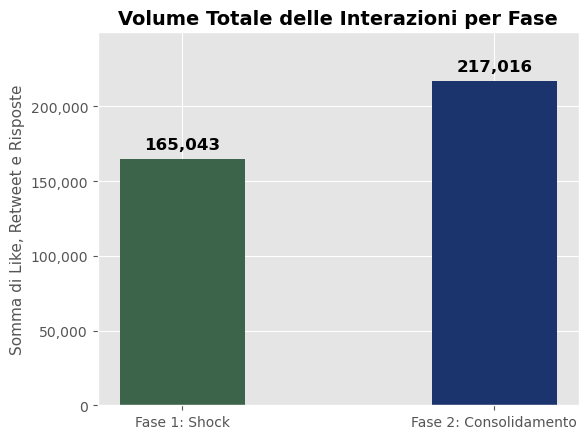

In [ ]:
import matplotlib.pyplot as plt

# GRAFICO DIFFERENZA VOLUMI DELLE INTERAZIONI TRA LE DUE FASI
fasi = ["Fase 1: Shock", "Fase 2: Consolidamento"] # Etichette più descrittive
volumi_fasi = [interazioni_fase_1, interazioni_fase_2]

colori = ['#3C644B', '#1C346E'] 

fig, ax = plt.subplots(figsize=(6, 4.5))
barre = ax.bar(fasi, volumi_fasi, color=colori, width=0.4)

ax.bar_label(barre, fmt='{:,.0f}', padding=5, fontsize=12, fontweight='bold')

ax.set_title('Volume Totale delle Interazioni per Fase', fontsize=14, fontweight='bold')
ax.set_ylabel('Somma di Like, Retweet e Risposte', fontsize=11)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

ax.margins(y=0.15)

plt.tight_layout()
plt.savefig('volume_interazioni_due_fasi_ridotto.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
media_fase1 = (df_fase1['like'].sum() + df_fase1['retweet'].sum()) / len(df_fase1)
media_fase2 = (df_fase2['like'].sum() + df_fase2['retweet'].sum()) / len(df_fase2)

print(f"Interazioni MEDIE per tweet nella Fase 1: {int(media_fase1)}")
print(f"Interazioni MEDIE per tweet nella Fase 2: {int(media_fase2)}")

Interazioni MEDIE per tweet nella Fase 1: 61
Interazioni MEDIE per tweet nella Fase 2: 156


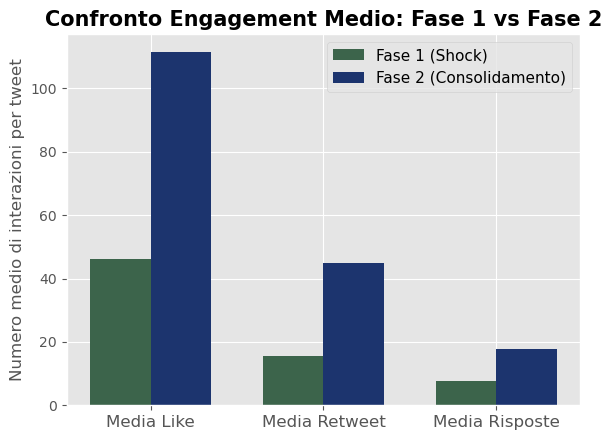

In [ ]:
# GRAFICO DELL' ENGAGEMENT MEDIO
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(6, 4.5))

metriche = ['Media Like', 'Media Retweet', 'Media Risposte']

medie_f1 = [df_fase1['like'].mean(), df_fase1['retweet'].mean(), df_fase1['risposte'].mean()]
medie_f2 = [df_fase2['like'].mean(), df_fase2['retweet'].mean(), df_fase2['risposte'].mean()]

x = range(len(metriche))
width = 0.35

ax.bar([i - width/2 for i in x], medie_f1, width, label='Fase 1 (Shock)', color='#3C644B')
ax.bar([i + width/2 for i in x], medie_f2, width, label='Fase 2 (Consolidamento)', color='#1C346E')

ax.set_ylabel('Numero medio di interazioni per tweet', fontsize=12)
ax.set_title('Confronto Engagement Medio: Fase 1 vs Fase 2', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metriche, fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda_engagement_medio_fasi.png', dpi=300, bbox_inches='tight')
plt.show()

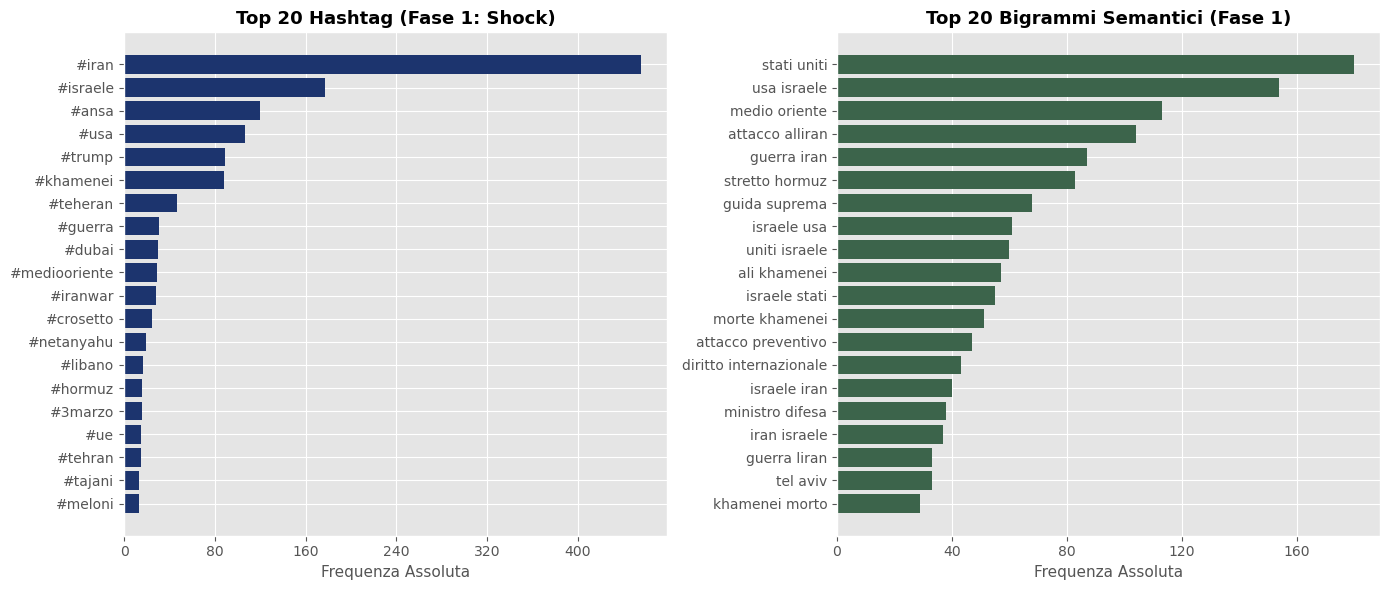

In [ ]:
# ESTRAZIONE TOP HASHTAG E BIGRAMMI NELLA PRIMA FASE (per mostrare il prima e il dopo e come si è spostato il focus dell'attenzione)
nltk.download('stopwords', quiet=True)
stop_words_it = set(stopwords.words('italian'))
# Aggiunta di stopwords custom comuni su X
stop_words_it.update(['c', 'i', 'in', 'di', 'a', 'da', 'su', 'per', 'con', 'tra', 'fra', 'il', 'la', 'le', 'un', 'una', 'che', 'non', 'si', 'è', 'ha', 'del', 'della', 'dei', 'delle', 'al', 'alla', 'ai', 'alle', 'nel', 'nella', 'nei', 'nelle', 'sul', 'sulla', 'sui', 'sulle', 'più', 'come', 'ma', 'questo', 'questa', 'quello', 'quella'])

def pulisci_testo_bigrammi(testo):
    if not isinstance(testo, str):
        return ""
    testo = re.sub(r'http\S+|www\S+|https\S+', '', testo, flags=re.MULTILINE) # Rimuove URL
    testo = re.sub(r'@\w+', '', testo) # Rimuove Menzioni
    testo = re.sub(r'[^\w\s]', '', testo) # Rimuove Punteggiatura
    testo = re.sub(r'\d+', '', testo) # Rimuove Numeri
    testo = testo.lower()
    parole = [parola for parola in testo.split() if parola not in stop_words_it and len(parola) > 2]
    return parole

# 1. Estrazione degli Hashtag dalla Fase 1 
hashtags_fase1 = []
for testo in df_fase1['testo'].dropna():
    trovati = re.findall(r"#\w+", testo.lower())
    hashtags_fase1.extend(trovati)

top_20_hashtags_f1 = Counter(hashtags_fase1).most_common(20)
df_hashtags_f1 = pd.DataFrame(top_20_hashtags_f1, columns=['Hashtag', 'Frequenza']).sort_values(by='Frequenza', ascending=True)

# 2. Estrazione dei Bigrammi dalla Fase 1 
bigrammi_fase1 = []
for testo in df_fase1['testo'].dropna():
    parole_pulite = pulisci_testo_bigrammi(testo)
    if len(parole_pulite) >= 2:
        bigrammi = list(ngrams(parole_pulite, 2))
        bigrammi_str = [" ".join(b) for b in bigrammi]
        bigrammi_fase1.extend(bigrammi_str)

top_20_bigrammi_f1 = Counter(bigrammi_fase1).most_common(20)
df_bigrammi_f1 = pd.DataFrame(top_20_bigrammi_f1, columns=['Bigrammo', 'Frequenza']).sort_values(by='Frequenza', ascending=True)

# 3. Generazione del grafico comparativo per la Fase 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico Hashtag Fase 1
ax1.barh(df_hashtags_f1['Hashtag'], df_hashtags_f1['Frequenza'], color='#1C346E') 
ax1.set_title('Top 20 Hashtag (Fase 1: Shock)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Frequenza Assoluta', fontsize=11)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

# Grafico Bigrammi Fase 1
ax2.barh(df_bigrammi_f1['Bigrammo'], df_bigrammi_f1['Frequenza'], color='#3C644B') 
ax2.set_title('Top 20 Bigrammi Semantici (Fase 1)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Frequenza Assoluta', fontsize=11)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

plt.tight_layout()
plt.savefig('eda_polarizzazione_fase1.png', dpi=300, bbox_inches='tight')
plt.show()


ANALISI RISULTATI TOP HASHTAG E BIGRAMMI PRIMA FASE
L'estrazione degli hashtag, dei bigrammi e dei Top 10 Utenti nei primissimi giorni del conflitto (28 Febbraio - 4 Marzo) restituisce la fotografia di un ecosistema concentrato sull'**azione cinetica** e sulla **cronaca pura**.

* **Focus Militare e Tattico:** Nei bigrammi spiccano termini legati all'immediatezza dell'azione militare e alle sue conseguenze dirette: "attacco preventivo", "morte khamenei", "khamenei morto", "ministro difesa" (correlato all'hashtag `#crosetto`).
* **L'Egemonia della Fonte Ufficiale:** Il bisogno di ricevere conferme su un evento in rapido sviluppo premia le testate istituzionali e i giornalisti sul campo. L'account che genera il maggior volume di interazioni in assoluto è `Agenzia_Ansa`, seguito da giornalisti e direttori di testata (es. `MarianoGiustino`, `Tommasocerno`, `AzzurraBarbuto`) e aggregatori di notizie (`ultimoranet`). In questa fase, l'utente medio usa X per leggere la "breaking news".

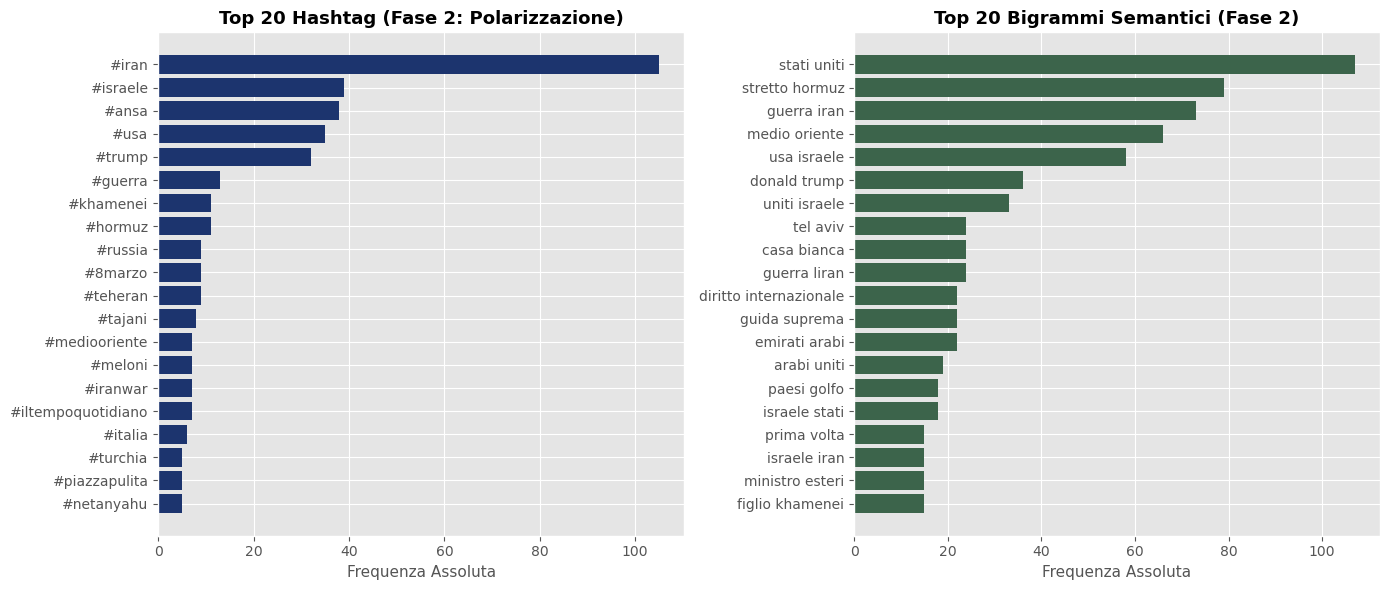

In [ ]:
# ESTRAZIONE TOP HASHTAG E BIGRAMMI NELLA SECONDA FASE
hashtags_fase2 = []
for testo in df_fase2['testo'].dropna():
    trovati = re.findall(r"#\w+", testo.lower())
    hashtags_fase2.extend(trovati)

top_20_hashtags = Counter(hashtags_fase2).most_common(20)
df_hashtags = pd.DataFrame(top_20_hashtags, columns=['Hashtag', 'Frequenza']).sort_values(by='Frequenza', ascending=True)

bigrammi_fase2 = []
for testo in df_fase2['testo'].dropna():
    parole_pulite = pulisci_testo_bigrammi(testo)
    if len(parole_pulite) >= 2:
        bigrammi = list(ngrams(parole_pulite, 2))
        bigrammi_str = [" ".join(b) for b in bigrammi]
        bigrammi_fase2.extend(bigrammi_str)

top_20_bigrammi = Counter(bigrammi_fase2).most_common(20)
df_bigrammi = pd.DataFrame(top_20_bigrammi, columns=['Bigrammo', 'Frequenza']).sort_values(by='Frequenza', ascending=True)

plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(df_hashtags['Hashtag'], df_hashtags['Frequenza'], color='#1C346E')
ax1.set_title('Top 20 Hashtag (Fase 2: Polarizzazione)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Frequenza Assoluta', fontsize=11)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

ax2.barh(df_bigrammi['Bigrammo'], df_bigrammi['Frequenza'], color='#3C644B')
ax2.set_title('Top 20 Bigrammi Semantici (Fase 2)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Frequenza Assoluta', fontsize=11)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

plt.tight_layout()
plt.savefig('eda_polarizzazione_fase2.png', dpi=300, bbox_inches='tight')
plt.show()

ANALISI RISULTATI TOP HASHTAG E BIGRAMMI SECONDA FASE
Dal 5 al 10 Marzo, l'ecosistema subisce una trasformazione netta. Scompaiono i riferimenti agli attacchi militari diretti ("attacco preventivo", "morte khamenei") e si consolida un lessico legato all'**inquadramento macro-regionale** e al **dibattito d'opinione**.

Bigrammi: Locuzioni come diritto internazionale, ministro esteri, stretto hormuz, emirati arabi confermano che, superato lo shock iniziale, l'utente italiano (o perlomeno i tweet che hanno ricevuto più engagement) ha cercato di inquadrare l'evento a livello diplomatico e macro-economico.

* **Dalla Difesa agli Esteri:** Il focus istituzionale si sposta dall'ambito militare a quello diplomatico. Nei bigrammi, "ministro difesa" viene sostituito da "ministro esteri" (correlato agli hashtag `#tajani` e `#meloni`), ed emergono gli attori macro-regionali: "emirati arabi", "paesi golfo", "arabi uniti", "casa bianca", oltre all'ingresso di hashtag come `#russia` e `#turchia`.
* **Effetto "Second Screen":** La presenza di hashtag come `#piazzapulita` e `#iltempoquotidiano` dimostra che una parte del dibattito su X si è trasformata in un commento in tempo reale ai talk show televisivi italiani e alle prime pagine dei giornali.
* **Il Cambio degli Attori (Opinionisti e Reti Alternative):** Il cambiamento più radicale avviene nei Top Utenti. La fonte istituzionale per eccellenza (`Agenzia_Ansa`) crolla dal 1° al 6° posto. Al vertice sale l'aggregatore rapido `ultimoranet`, ma soprattutto fanno il loro ingresso account fortemente polarizzati, orientati all'opinione o all'analisi geopolitica di parte, come `CesareSacchetti`, `rulajebreal` e il `fattoquotidiano`. L'ecosistema premia chi offre una "chiave di lettura" forte, non chi riporta il fatto nudo e crudo.

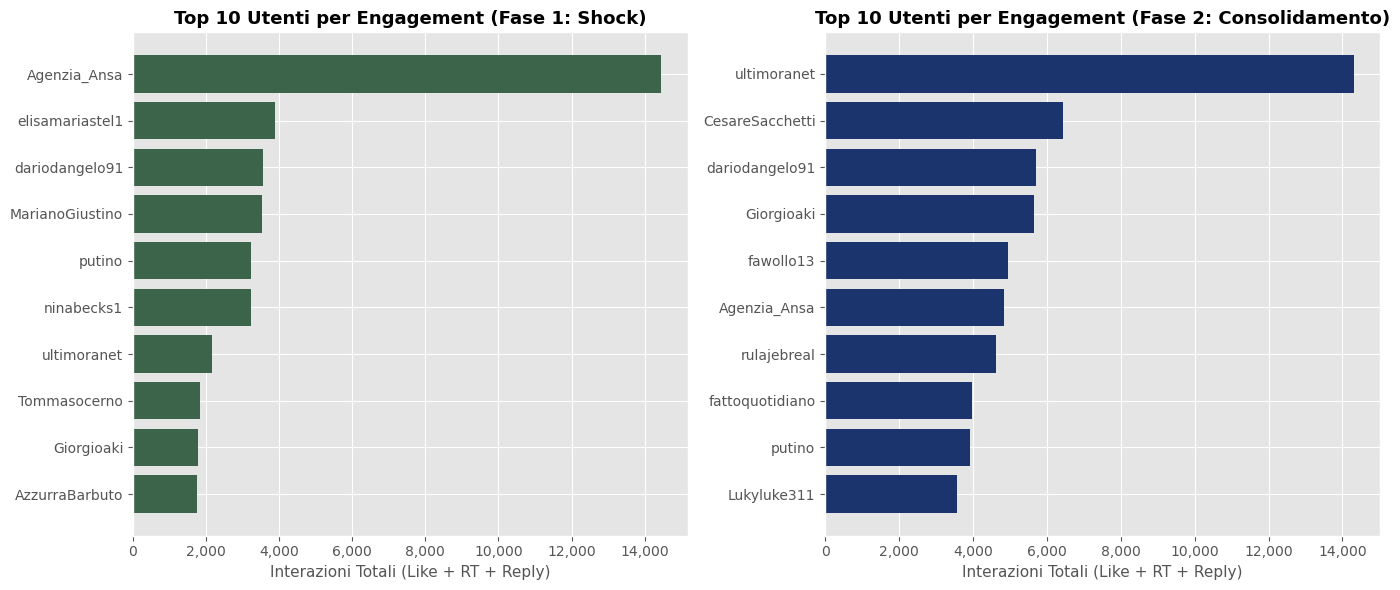

In [ ]:
# ESTRAZIONE TOP ATTORI PER ENTRAMBE LE FASI
df_fase1['engagement_totale'] = df_fase1['like'] + df_fase1['retweet'] + df_fase1['risposte']
df_fase2['engagement_totale'] = df_fase2['like'] + df_fase2['retweet'] + df_fase2['risposte']

# 2. Raggruppamento per utente e somma dell'engagement per la Fase 1
top_utenti_f1 = df_fase1.groupby('username')['engagement_totale'].sum().reset_index()
top_utenti_f1 = top_utenti_f1.sort_values(by='engagement_totale', ascending=False).head(10)
top_utenti_f1 = top_utenti_f1.sort_values(by='engagement_totale', ascending=True) # Ordine per il plot dal basso

# 3. Raggruppamento per utente e somma dell'engagement per la Fase 2
top_utenti_f2 = df_fase2.groupby('username')['engagement_totale'].sum().reset_index()
top_utenti_f2 = top_utenti_f2.sort_values(by='engagement_totale', ascending=False).head(10)
top_utenti_f2 = top_utenti_f2.sort_values(by='engagement_totale', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico Top Utenti Fase 1
ax1.barh(top_utenti_f1['username'], top_utenti_f1['engagement_totale'], color='#3C644B')
ax1.set_title('Top 10 Utenti per Engagement (Fase 1: Shock)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Interazioni Totali (Like + RT + Reply)', fontsize=11)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Grafico Top Utenti Fase 2
ax2.barh(top_utenti_f2['username'], top_utenti_f2['engagement_totale'], color='#1C346E')
ax2.set_title('Top 10 Utenti per Engagement (Fase 2: Consolidamento)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Interazioni Totali (Like + RT + Reply)', fontsize=11)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig('eda_top_utenti_fasi.png', dpi=300, bbox_inches='tight')
plt.show()

2° LIVELLO
analisi del corpus intero

In [24]:
df_totale = pd.concat([df_fase1, df_fase2]).reset_index(drop=True)
df_totale.head()

,id,data_ora,username,testo,mentions,in_reply_to,retweet,like,risposte,url
0,2027521218736177237,2026-02-28 00:08:22+01:00,loidomemau,Israele Stato Nazista Satanista Pedofilo Terro...,NaN,NaN,1,6,0,https://x.com/loidomemau/status/20275212187361...
1,2027522070460903569,2026-02-28 00:11:45+01:00,loidomemau,I giornalisti ci sono e come! Solo che quelli ...,NaN,NaN,0,4,0,https://x.com/loidomemau/status/20275220704609...
2,2027528194484801958,2026-02-28 00:36:05+01:00,eziomauro,"Iran, Trump: “Non voglio una soluzione militar...",NaN,NaN,0,3,0,https://x.com/eziomauro/status/202752819448480...
3,2027534885125005810,2026-02-28 01:02:41+01:00,Adnkronos,"Iran, il verdetto di Trump e l'apertura di Teh...",NaN,NaN,0,0,0,https://x.com/Adnkronos/status/202753488512500...
4,2027535746756641078,2026-02-28 01:06:06+01:00,Aramcheck76,La registrazione della #pendolaria di ieri ser...,"EdoardoFontana7,AleGuerani",NaN,7,13,0,https://x.com/Aramcheck76/status/2027535746756...


In [ ]:
# PRIMO TWEET SU KHAMENEI per conferma orario
tweet_con_khamenei = df_totale[df_totale['testo'].str.lower().str.contains('khamenei', na=False)]

tweet_con_khamenei = tweet_con_khamenei.sort_values(by='data_ora')

if not tweet_con_khamenei.empty:
    primo_tweet = tweet_con_khamenei.iloc[0]
    
    print("=== IL PRIMO TWEET SU KHAMENEI ===")
    print(f"Data e Ora: {primo_tweet['data_ora']}")
    print(f"Utente: @{primo_tweet['username']}")
    print(f"Testo: {primo_tweet['testo']}")
    print(f"Metriche: {primo_tweet['like']} Like, {primo_tweet['retweet']} Retweet")
    print(f"Link: {primo_tweet['url']}")
else:
    print("Nessun tweet trovato con la parola 'khamenei'.")

=== IL PRIMO TWEET SU KHAMENEI ===
Data e Ora: 2026-02-28 07:49:01+01:00
Utente: @ROBZIK
Testo: La televisione di Stato dell’Iran ha confermato un'esplosione nella zona degli uffici della Guida Suprema Ayatollah Ali Khamenei provocata dall’attacco israeliano. Non è chiaro se Khamenei fosse nei suoi uffici al momento dell'esplosione.
Metriche: 10 Like, 6 Retweet
Link: https://x.com/ROBZIK/status/2027637145326768351


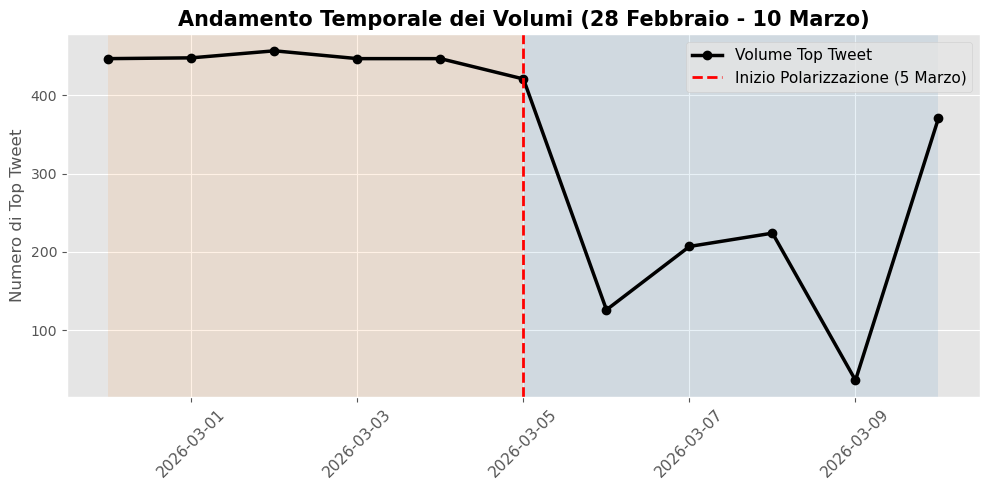

In [ ]:
# GRAFICO DELL'ANDAMENTO TEMPORALE
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(10, 5))

df_totale['solo_data'] = df_totale['data_ora'].dt.date
volumi_totali = df_totale.groupby('solo_data').size()

ax.plot(volumi_totali.index, volumi_totali.values, marker='o', color='black', linewidth=2.5, label='Volume Top Tweet')

data_spartiacque = pd.to_datetime('2026-03-05').date()

ax.axvline(x=data_spartiacque, color='red', linestyle='--', linewidth=2, label='Inizio Polarizzazione (5 Marzo)')
ax.axvspan(volumi_totali.index.min(), data_spartiacque, facecolor='#ff7f0e', alpha=0.1)
ax.axvspan(data_spartiacque, volumi_totali.index.max(), facecolor='#1f77b4', alpha=0.1)

ax.set_ylabel('Numero di Top Tweet', fontsize=12)
ax.set_title('Andamento Temporale dei Volumi (28 Febbraio - 10 Marzo)', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda_andamento_volumi_totale.png', dpi=300, bbox_inches='tight')
plt.show()

In [47]:
# DIAGNOSTICA: capire perché non vengono trovati retweet
# Prima cosa: quanti tweet nel corpus totale contengono "RT" nel testo?
contiene_rt = df_totale['testo'].str.contains('RT', na=False).sum()
print(f"Tweet che contengono 'RT': {contiene_rt} su {len(df_totale)} totali")

# Seconda cosa: mostriamo i primi 5 tweet che contengono RT,
# così vediamo esattamente come sono formattati
esempi_rt = df_totale[df_totale['testo'].str.contains('^RT', na=False, regex=True)].head(5)
print("\nEsempi di tweet che iniziano con RT:")
for i, row in esempi_rt.iterrows():
    # repr() mostra i caratteri invisibili come \n, \r, spazi extra ecc.
    print(repr(row['testo'][:100]))

# Terza cosa: proviamo a vedere i primi caratteri del primo tweet
# per escludere problemi di BOM o encoding
print("\nPrimi 10 caratteri del primo tweet (in repr):")
print(repr(df_totale['testo'].iloc[0][:10]))

Tweet che contengono 'RT': 45 su 3631 totali

Esempi di tweet che iniziano con RT:

Primi 10 caratteri del primo tweet (in repr):
'Israele St'


In [48]:
# Lavoriamo sul dataset COMPLETO unito precedentemente
df_network = df_totale.copy()

# Funzione per estrarre l'utente target (chi viene retwittato)
def estrai_target(testo):
    if not isinstance(testo, str):
        return None
    
    # Cerchiamo il pattern del Retweet (RT @username:)
    rt_match = re.search(r'^RT @([A-Za-z0-9_]+):', testo)
    if rt_match:
        return rt_match.group(1)  
    # Se non è un RT, cerca la prima menzione @username
    mention_match = re.search(r'@([A-Za-z0-9_]+)', testo)
    if mention_match:
        return mention_match.group(1)
    return None

# Creiamo la colonna del target applicando la funzione
df_network['target'] = df_network['testo'].apply(estrai_target)

# Rimuoviamo i tweet che non contengono interazioni (i tweet isolati non creano rete)
df_archi = df_network.dropna(subset=['target'])

# Costruiamo la Edge List: chi (source) interagisce con chi (target)
edge_list = df_archi[['username', 'target']].rename(columns={'username': 'source'})

# Calcoliamo il 'peso' della relazione (quante volte la sorgente ha interagito con il target)
edge_list_pesata = edge_list.groupby(['source', 'target']).size().reset_index(name='weight')

# Ordiniamo per peso decrescente per vedere le interazioni più forti
edge_list_pesata = edge_list_pesata.sort_values(by='weight', ascending=False).reset_index(drop=True)

# Esportiamo la Edge List in un file CSV pronto per essere importato in software come Gephi
# o per essere usato con NetworkX
edge_list_pesata.to_csv('edge_list_totale.csv', index=False)

# Mostriamo il riepilogo
print("=== EDGE LIST TOTALE (28 Feb - 10 Mar) ===")
print(f"Numero totale di archi (relazioni uniche): {len(edge_list_pesata)}")
print("\nPrime 15 relazioni più forti dell'ecosistema:")
display(edge_list_pesata.head(15))

=== EDGE LIST TOTALE (28 Feb - 10 Mar) ===
Numero totale di archi (relazioni uniche): 206

Prime 15 relazioni più forti dell'ecosistema:


,source,target,weight
0,BMitraglia,LionUdler,6
1,Tommasocerno,ilgiornale,6
2,radio3mondo,battgirl74,5
3,radioanchio,Radio1Rai,4
4,MarianoGiustino,RadioRadicale,4
5,DanieleDann1,Emergenza24,4
6,fattoquotidiano,salvini_giacomo,4
7,francofontana43,oss_romano,3
8,malberizzi,africexp,3
9,tempoweb,Capezzone,3


=== STATISTICHE DEL NETWORK ===
Nodi totali (Utenti coinvolti): 306
Archi totali (Relazioni uniche): 206


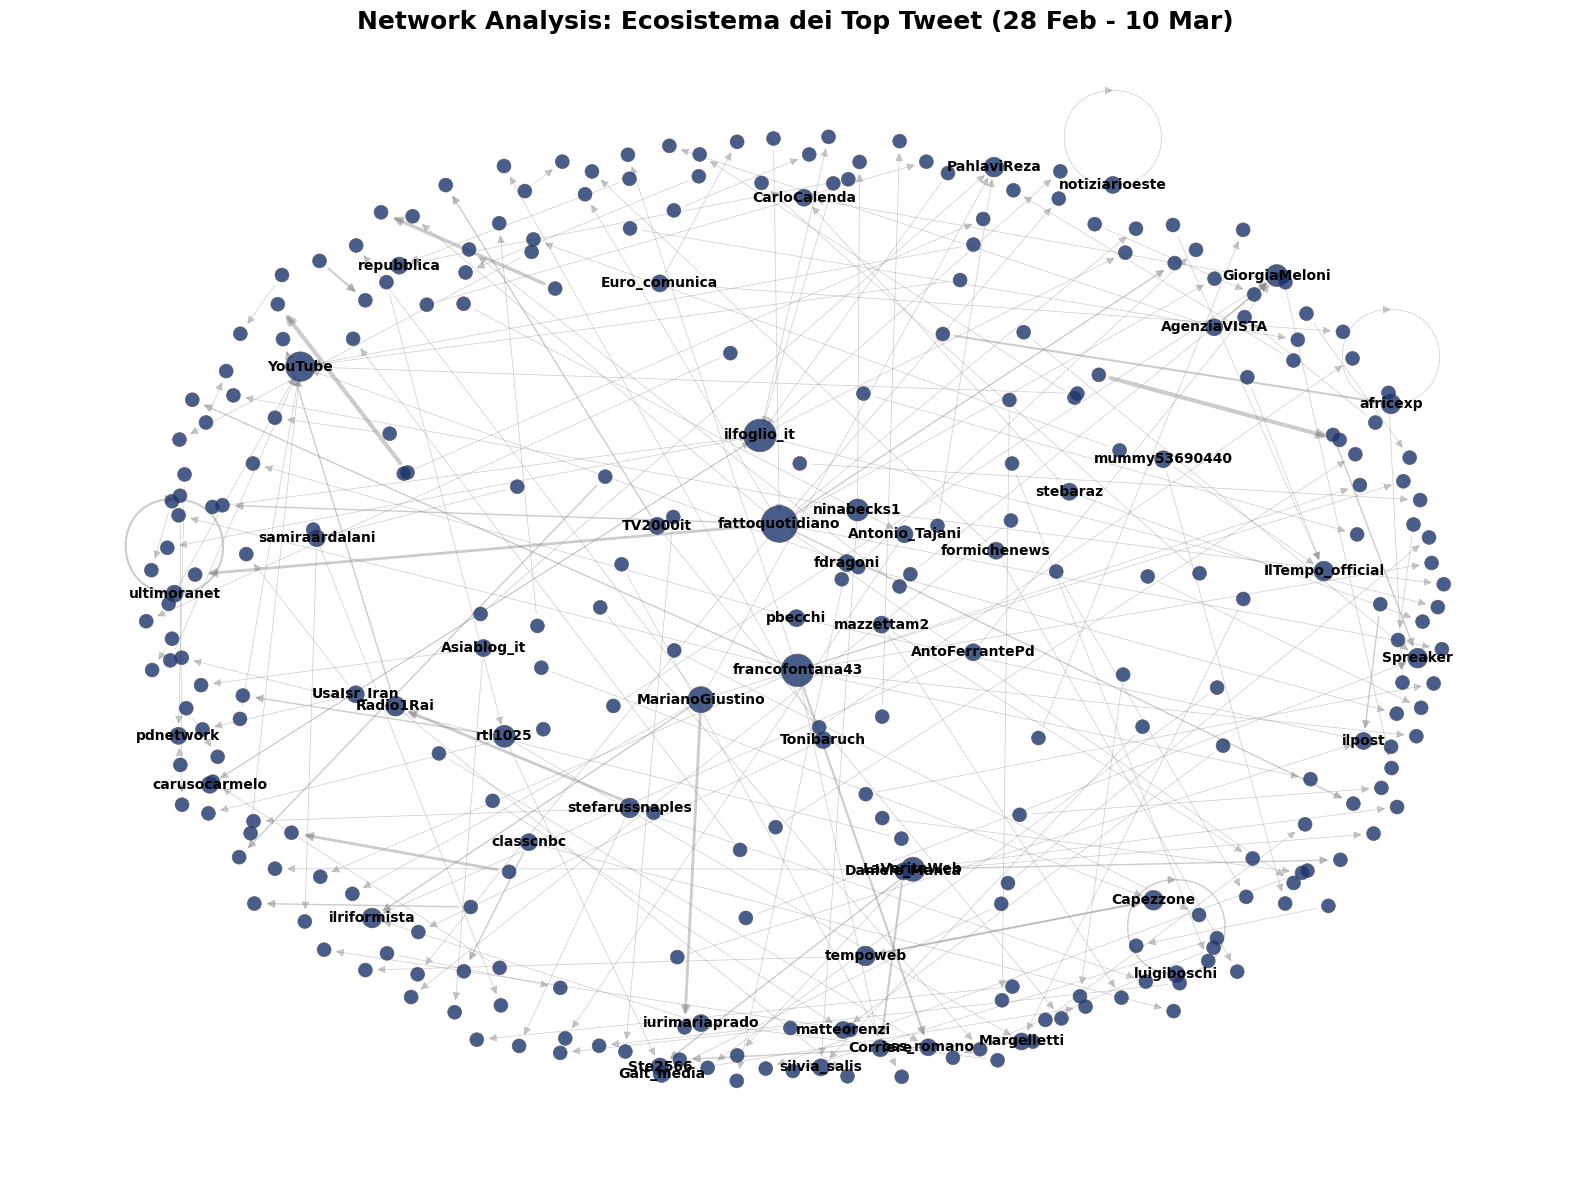

In [ ]:
# Inizializzazione del Grafo Diretto 
G = nx.from_pandas_edgelist(edge_list_pesata, source='source', target='target', edge_attr='weight', create_using=nx.DiGraph())

print("=== STATISTICHE DEL NETWORK ===")
print(f"Nodi totali (Utenti coinvolti): {G.number_of_nodes()}")
print(f"Archi totali (Relazioni uniche): {G.number_of_edges()}")

# Calcolo della Centralità (Degree)
# Contiamo quante connessioni ha ogni nodo per poterne variare la grandezza nel grafico
gradi = dict(G.degree())

plt.figure(figsize=(16, 12))

# Algoritmo di Spazializzazione (Spring Layout / Fruchterman-Reingold)
# k=0.5 distanzia i nodi, iterations=50 calcola l'attrazione fisica
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Disegno dei NODI
# I nodi avranno una dimensione proporzionale alla loro importanza
dimensioni_nodi = [v * 50 + 50 for v in gradi.values()]
nx.draw_networkx_nodes(G, pos, node_size=dimensioni_nodi, node_color='#1C346E', alpha=0.8, edgecolors='#50505F')

# Disegno degli ARCHI
# Lo spessore degli archi dipenderà dal 'weight' (es. quanti RT ha fatto A verso B)
pesi_archi = [G[u][v]['weight'] * 0.5 for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, width=pesi_archi, edge_color='gray', alpha=0.4, arrows=True, arrowsize=12)

# Etichette Intelligenti
# Mostriamo i nomi SOLO dei nodi più importanti (grado > 1) per non trasformare il grafico in una macchia nera illeggibile
etichette = {nodo: nodo if grado > 1 else "" for nodo, grado in gradi.items()}
nx.draw_networkx_labels(G, pos, labels=etichette, font_size=10, font_weight='bold')

# 8. Formattazione e Salvataggio
plt.title("Network Analysis: Ecosistema dei Top Tweet (28 Feb - 10 Mar)", fontsize=18, fontweight='bold')
plt.axis('off') # Rimuove le assi X e Y per un look più pulito
plt.tight_layout()
plt.savefig('network_strutturale_base.png', dpi=300, bbox_inches='tight')
plt.show()

=== COMMUNITY DETECTION ===
L'algoritmo ha individuato 106 macro-comunità principali.


C:\Users\ignaz\AppData\Local\Temp\ipykernel_20888\542774663.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set2', max(node_community.values()) + 1)


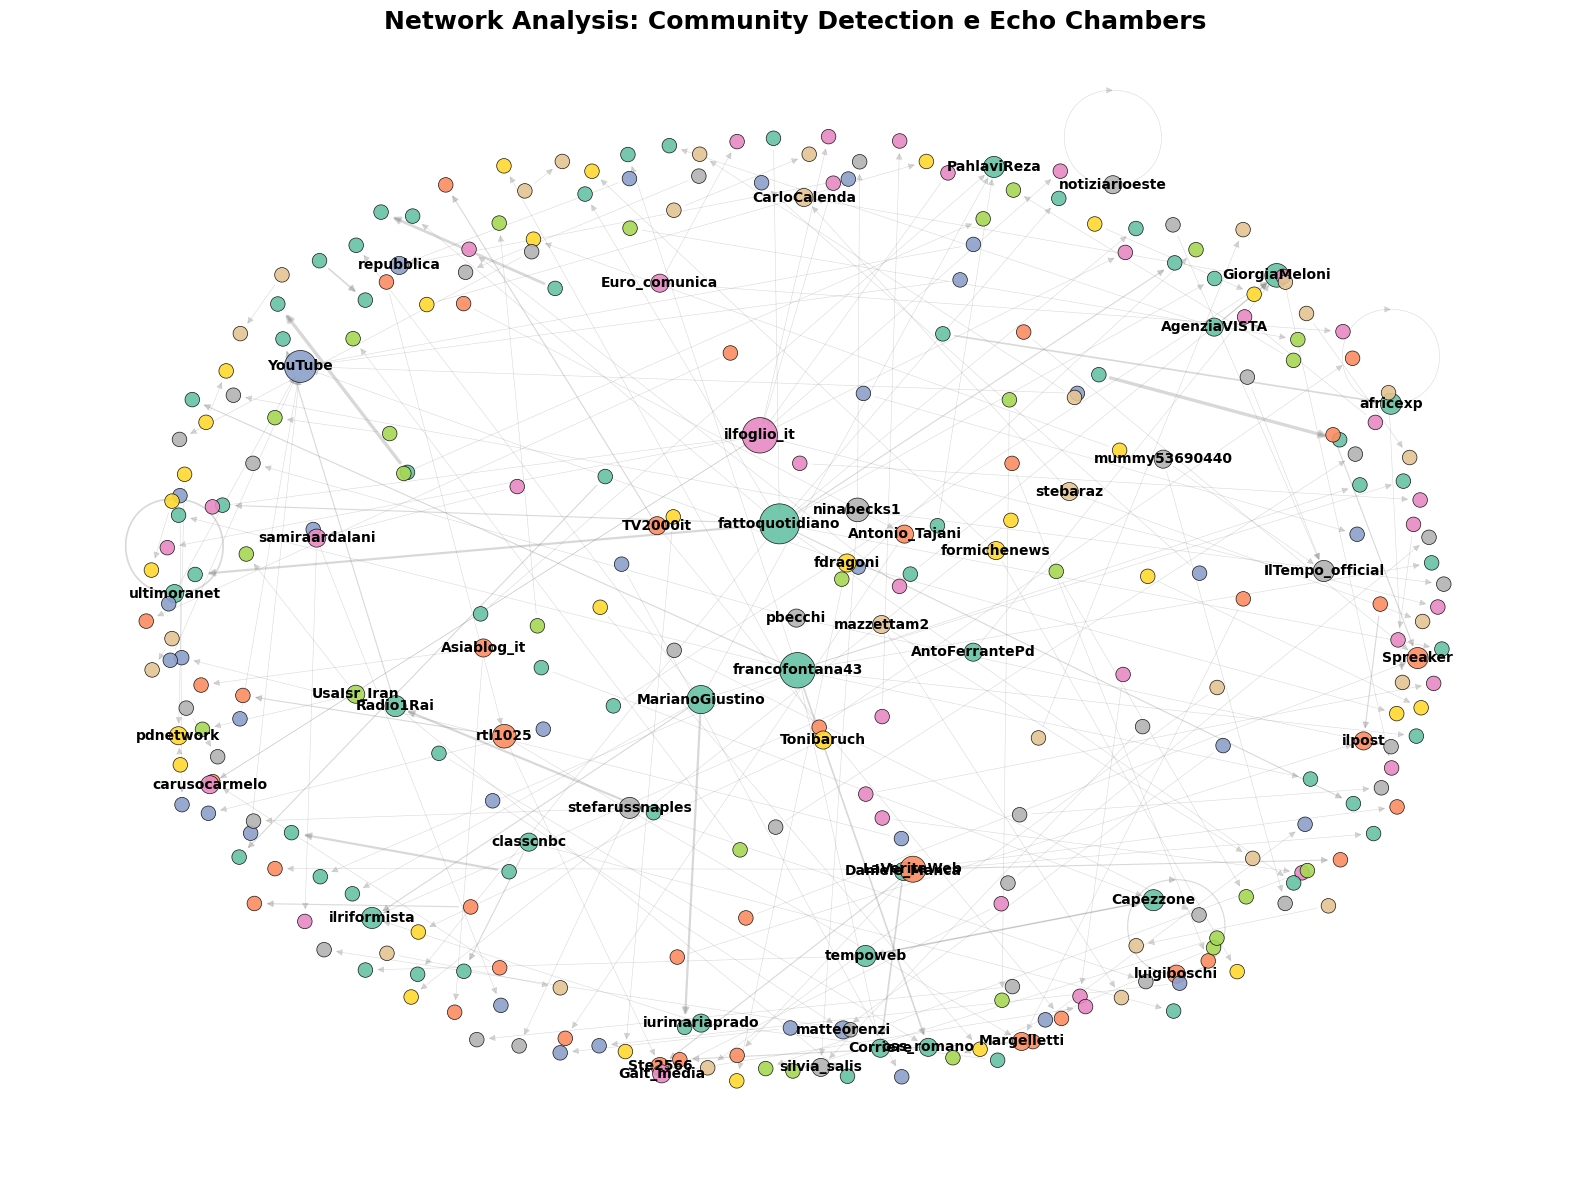

In [50]:
# 1. Ricostruiamo il grafo partendo dalla Edge List
G = nx.from_pandas_edgelist(edge_list_pesata, source='source', target='target', edge_attr='weight', create_using=nx.DiGraph())

# L'algoritmo di Louvain per il partizionamento ottimale lavora sui grafi non diretti
G_undirected = G.to_undirected()

# 2. Applichiamo l'algoritmo di Louvain per isolare le Echo Chambers
communities = nx.community.louvain_communities(G_undirected, weight='weight', seed=42)

print("=== COMMUNITY DETECTION ===")
print(f"L'algoritmo ha individuato {len(communities)} macro-comunità principali.")

# Creiamo un dizionario per mappare ogni nodo al suo numero di community
node_community = {}
for i, com in enumerate(communities):
    for node in com:
        node_community[node] = i

# 3. Impostiamo il layout spaziale (Gravità)
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# 4. Assegnazione dei Colori
# Generiamo una mappa di colori in base al numero di fazioni rilevate
cmap = plt.cm.get_cmap('Set2', max(node_community.values()) + 1)
colori_nodi = [cmap(node_community[node]) for node in G.nodes()]

# Calcoliamo le dimensioni dei nodi in base alla Centralità (Grado)
gradi = dict(G.degree())
dimensioni_nodi = [v * 60 + 50 for v in gradi.values()]

# 5. Rendering Visivo di Nodi e Archi
nx.draw_networkx_nodes(G, pos, node_size=dimensioni_nodi, node_color=colori_nodi, alpha=0.9, edgecolors='black')

pesi_archi = [G[u][v]['weight'] * 0.4 for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, width=pesi_archi, edge_color='gray', alpha=0.3, arrows=True)

# 6. Etichette selettive (mostra i nomi solo degli hub per mantenere il grafico leggibile)
etichette = {nodo: nodo if grado > 1 else "" for nodo, grado in gradi.items()}
nx.draw_networkx_labels(G, pos, labels=etichette, font_size=10, font_weight='bold')

plt.title("Network Analysis: Community Detection e Echo Chambers", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('network_communities_louvain.png', dpi=300, bbox_inches='tight')
plt.show()

In [51]:
# METRICHE QUANTITATIVE PER LA NETWORK ANALYSIS
# Questo blocco traduce i grafi visuali in numeri citabili nel report

# 1. MODULARITÀ
# Misura la "forza" delle community: 0 = rete casuale, 1 = community perfettamente separate
# Un valore tra 0.3 e 0.7 indica una struttura di community moderata/forte
modularita = nx.community.modularity(G_undirected, communities, weight='weight')
print(f"Modularità della rete: {modularita:.4f}")

# 2. DENSITÀ INTRA vs INTER COMMUNITY
# Per capire se le community si parlano tra loro o vivono in bolle separate,
# calcoliamo quante connessioni avvengono DENTRO ogni community rispetto a quelle che vanno FUORI
print("\n=== DENSITÀ INTRA/INTER COMMUNITY (Top 5 community per dimensione) ===")
top_communities = sorted(communities, key=len, reverse=True)[:5]

for i, com in enumerate(top_communities):
    nodi_com = set(com)
    archi_interni = sum(1 for u, v in G_undirected.edges() if u in nodi_com and v in nodi_com)
    archi_esterni = sum(1 for u, v in G_undirected.edges() if (u in nodi_com) != (v in nodi_com))
    totale = archi_interni + archi_esterni
    ratio = archi_interni / totale if totale > 0 else 0
    print(f"Community {i+1} ({len(com)} nodi): {archi_interni} archi interni, "
          f"{archi_esterni} esterni → {ratio:.1%} connessioni interne")

# 3. BETWEENNESS CENTRALITY (i "ponti" tra community)
# Gli utenti con alta betweenness sono quelli che collegano fazioni diverse:
# giornalisti seguiti da tutti, account che vengono citati trasversalmente
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)
top_bridge_nodes = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\n=== TOP 10 BRIDGE NODES (utenti che collegano community diverse) ===")
for nodo, score in top_bridge_nodes:
    com_id = node_community.get(nodo, '?')
    print(f"@{nodo}: betweenness={score:.4f} (community {com_id})")

# 4. IN-DEGREE CENTRALITY (chi viene più citato/retweettato)
# Nel grafo diretto, l'in-degree misura quante frecce arrivano verso un nodo:
# più frecce = più retweet/menzioni ricevuti = maggiore autorevolezza nella rete
in_degree = nx.in_degree_centrality(G)
top_in_degree = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:10]
print("\n=== TOP 10 NODI PER IN-DEGREE (hub informativi della rete) ===")
for nodo, score in top_in_degree:
    print(f"@{nodo}: in-degree={score:.4f}")

Modularità della rete: 0.9717

=== DENSITÀ INTRA/INTER COMMUNITY (Top 5 community per dimensione) ===
Community 1 (17 nodi): 16 archi interni, 0 esterni → 100.0% connessioni interne
Community 2 (14 nodi): 13 archi interni, 0 esterni → 100.0% connessioni interne
Community 3 (14 nodi): 13 archi interni, 0 esterni → 100.0% connessioni interne
Community 4 (11 nodi): 10 archi interni, 0 esterni → 100.0% connessioni interne
Community 5 (10 nodi): 9 archi interni, 0 esterni → 100.0% connessioni interne

=== TOP 10 BRIDGE NODES (utenti che collegano community diverse) ===
@ilfoglio_it: betweenness=0.0002 (community 42)
@fattoquotidiano: betweenness=0.0001 (community 6)
@rtl1025: betweenness=0.0000 (community 20)
@Radio1Rai: betweenness=0.0000 (community 3)
@tempoweb: betweenness=0.0000 (community 9)
@Capezzone: betweenness=0.0000 (community 9)
@Antonio_Tajani: betweenness=0.0000 (community 24)
@iurimariaprado: betweenness=0.0000 (community 4)
@samiraardalani: betweenness=0.0000 (community 45)


In [52]:
# Creiamo un DataFrame che associa ogni nodo alla sua community e al suo grado (importanza)
dati_nodi = []
for nodo, com_id in node_community.items():
    grado = G.degree(nodo)
    dati_nodi.append({'Utente': nodo, 'Community': com_id, 'Grado': grado})

df_communities = pd.DataFrame(dati_nodi)

# Contiamo quanti utenti ci sono in ogni community per trovare le più grandi
dimensioni_com = df_communities['Community'].value_counts()

print("=== IDENTIKIT DELLE MACRO-COMUNITÀ ===")
# Analizziamo solo le comunità che hanno almeno 5 membri (ignoriamo le micro-bolle isolate)
comunita_principali = dimensioni_com[dimensioni_com >= 5].index

for com_id in comunita_principali:
    membri_totali = dimensioni_com[com_id]
    # Estraiamo i membri di questa specifica community
    membri = df_communities[df_communities['Community'] == com_id]
    # Ordiniamo per importanza (Grado) e prendiamo i primi 5
    top_membri = membri.sort_values(by='Grado', ascending=False).head(5)
    
    print(f"\n[ Community {com_id} ] - Dimensione: {membri_totali} utenti centrali")
    print("Hub principali:")
    for _, row in top_membri.iterrows():
        print(f"  - @{row['Utente']} (Grado: {row['Grado']})")

=== IDENTIKIT DELLE MACRO-COMUNITÀ ===

[ Community 4 ] - Dimensione: 17 utenti centrali
Hub principali:
  - @MarianoGiustino (Grado: 6)
  - @GiorgiaMeloni (Grado: 4)
  - @ilriformista (Grado: 3)
  - @PahlaviReza (Grado: 3)
  - @iurimariaprado (Grado: 2)

[ Community 6 ] - Dimensione: 14 utenti centrali
Hub principali:
  - @fattoquotidiano (Grado: 13)
  - @Snaporaz92 (Grado: 1)
  - @cosimocaridi (Grado: 1)
  - @scannavo (Grado: 1)
  - @robertazunini (Grado: 1)

[ Community 7 ] - Dimensione: 14 utenti centrali
Hub principali:
  - @francofontana43 (Grado: 10)
  - @Daniele_Manca (Grado: 2)
  - @Corriere (Grado: 2)
  - @oss_romano (Grado: 2)
  - @martaserafini (Grado: 1)

[ Community 20 ] - Dimensione: 11 utenti centrali
Hub principali:
  - @LaVeritaWeb (Grado: 5)
  - @rtl1025 (Grado: 4)
  - @Ste2566 (Grado: 2)
  - @Margelletti (Grado: 2)
  - @gandolag (Grado: 1)

[ Community 42 ] - Dimensione: 10 utenti centrali
Hub principali:
  - @ilfoglio_it (Grado: 10)
  - @carusocarmelo (Grado: 2)
  